# Week 7 – Day 2
# Session 1

# Trustworthy Model Evaluation


# Why Model Evaluation Matters

Unlike previous algorithms, Decision Trees can become extremely complex if they are allowed to grow without restrictions.

This naturally leads to an important question:

> **If a model achieves 100% training accuracy, can we trust it?**

The answer is **not always**.





Suppose two students build two different machine learning models.

Model A reports

```
Accuracy = 98%
```

Model B reports

```
Accuracy = 92%
```

Question:

> Is Model A necessarily better?

Most beginners immediately answer:

> Yes.

Unfortunately, the answer is:

> **Not always.**

To understand why, we must first understand how models are evaluated.

---

# What Does "Good Model" Mean?

A good model should:

- Make accurate predictions.
- Generalize to unseen data.
- Produce consistent performance.
- Be robust against noise.
- Solve the intended business problem.

Evaluation metrics help us measure these properties objectively.

---

# Evaluation Metrics

Machine learning tasks require different evaluation metrics.

```
Regression

↓

Continuous Output

↓

MSE
RMSE
R²
```

```
Classification

↓

Discrete Classes

↓

Confusion Matrix

↓

Accuracy

Precision

Recall

F1-score
```

---

# Regression Metrics

## Mean Squared Error (MSE)

Measures the average squared prediction error.

$$
MSE=
\frac1n
\sum_{i=1}^{n}(y_i-\hat y_i)^2
$$

Characteristics:

- Penalizes large errors.
- Always non-negative.
- Lower values are better.

---

## Root Mean Squared Error (RMSE)

$$
RMSE=\sqrt{MSE}
$$

Advantages:

- Same units as the target variable.
- Easier to interpret.

---


# R-Squared (R²)

## Definition

**R-Squared (R²)**, also called the **coefficient of determination**, measures how much of the variation in the target variable is explained by a regression model.

The formula is:

$$
R^2 = 1 - \frac{SS_{res}}{SS_{tot}}
$$

where:

- $SS_{res}$ = Residual Sum of Squares (unexplained error)
- $SS_{tot}$ = Total Sum of Squares (total variation in the data)

---

# 1. Residual Sum of Squares ($SS_{res}$)

## Definition

The **Residual Sum of Squares** measures the difference between the actual target values and the values predicted by the model.

$$
SS_{res}=\sum_{i=1}^{n}(y_i-\hat{y_i})^2
$$

Where:

| Symbol | Meaning |
|---|---|
| $y_i$ | Actual target value |
| $\hat{y_i}$ | Model prediction |
| $n$ | Number of samples |

In simple terms:

> **SS_res represents the error that the model cannot explain.**

A smaller $SS_{res}$ means the predictions are closer to the actual values.

---

## Example

Suppose a model predicts house prices:

| Actual Price ($y$) | Predicted Price ($\hat{y}$) | Error | Squared Error |
|---|---|---|---|
| 10 | 9 | 1 | 1 |
| 15 | 14 | 1 | 1 |
| 20 | 18 | 2 | 4 |

Therefore:

$$
SS_{res}=1+1+4=6
$$

The model has a total prediction error of **6**.

---

# 2. Total Sum of Squares ($SS_{tot}$)

## Definition

The **Total Sum of Squares** measures the total variation of the target values around their mean.

$$
SS_{tot}=\sum_{i=1}^{n}(y_i-\bar{y})^2
$$

Where:

| Symbol | Meaning |
|---|---|
| $y_i$ | Actual target value |
| $\bar{y}$ | Mean of all target values |

In simple terms:

> **SS_tot represents how much the target values vary naturally before applying any model.**

---

## Example

Target values:

$$
y=[10,15,20]
$$

Mean:

$$
\bar{y}=15
$$

Calculation:

| Actual ($y$) | Mean ($\bar{y}$) | Difference | Squared Difference |
|---|---|---|---|
| 10 | 15 | -5 | 25 |
| 15 | 15 | 0 | 0 |
| 20 | 15 | 5 | 25 |

Therefore:

$$
SS_{tot}=25+0+25=50
$$

The total variation in the data is **50**.

---

# Relationship Between $SS_{res}$ and $SS_{tot}$

The total variation can be divided into two parts:

$$
SS_{tot}=SS_{res}+SS_{explained}
$$

Where:

| Term | Meaning |
|---|---|
| $SS_{tot}$ | Total variation in the target values |
| $SS_{res}$ | Variation not explained by the model |
| $SS_{explained}$ | Variation explained by the model |

Therefore:

$$
R^2=
1-\frac{\text{Unexplained Variation}}
{\text{Total Variation}}
$$

---

# Example Calculation of R²

Assume:

$$
SS_{tot}=10000
$$

and:

$$
SS_{res}=2000
$$

Then:

$$
R^2=1-\frac{2000}{10000}
$$

$$
R^2=1-0.2
$$

$$
R^2=0.8
$$

Interpretation:

> The model explains **80% of the variation** in the target variable.

The remaining:

$$
1-0.8=0.2
$$

or **20%** is unexplained error.

---

# Why R² = 0 Means Predicting the Mean

A simple baseline model predicts the average value for every sample:

$$
\hat{y_i}=\bar{y}
$$

In this case:

$$
SS_{res}=SS_{tot}
$$

Therefore:

$$
R^2=1-\frac{SS_{tot}}{SS_{tot}}
$$

$$
R^2=0
$$

Meaning:

> The model performs no better than simply predicting the average target value.

---

# Why R² Can Be Negative

Normally:

$$
0 \leq R^2 \leq 1
$$

However, R² can become negative when:

$$
SS_{res}>SS_{tot}
$$

which gives:

$$
R^2<0
$$

This means:

> The model performs worse than the baseline model that always predicts the mean.

This can happen when:

- The model is poorly trained.
- The features do not contain useful information.
- The model is applied to data outside its training distribution.

---

# Summary

| Concept | Formula | Meaning |
|---|---|---|
| $SS_{res}$ | $\sum(y_i-\hat{y_i})^2$ | Model prediction error |
| $SS_{tot}$ | $\sum(y_i-\bar{y})^2$ | Total variation in the data |
| $R^2$ | $1-\frac{SS_{res}}{SS_{tot}}$ | Percentage of variation explained by the model |

## Interpretation of R²

| R² Value | Meaning |
|---|---|
| 1 | Perfect predictions |
| 0 | Same performance as predicting the mean |
| < 0 | Worse than predicting the mean |


---

# Classification Metrics

Instead of measuring numerical error,

we compare predicted labels with actual labels.

---

# Confusion Matrix

Example:

| | Predicted Positive | Predicted Negative |
|---|---:|---:|
| Actual Positive | TP | FN |
| Actual Negative | FP | TN |

---

## True Positive (TP)

Correct positive prediction.

Example:

Patient has disease.

Model predicts disease.

---

## False Positive (FP)

Incorrect positive prediction.

Model predicts disease.

Patient is healthy.

---

## False Negative (FN)

Model predicts healthy.

Patient actually has disease.

---

## True Negative (TN)

Correct negative prediction.

---

# Accuracy

$$
Accuracy
=
\frac{TP+TN}
{TP+TN+FP+FN}
$$

Measures the percentage of correct predictions.

Easy to understand.

However,

it is not always reliable.

---

# Why Accuracy Is Not Enough 

Consider a fraud detection dataset.

```
99,000

Legitimate Transactions

1,000

Fraudulent Transactions
```

Suppose a model predicts

> Every transaction is legitimate.

Accuracy becomes

```
99%
```

Question:

Is the model useful?

Of course not.

It failed to detect every fraudulent transaction.

---


# Precision

$$
Precision
=
\frac{TP}
{TP+FP}
$$

Question answered:

> When the model predicts Positive,

how often is it correct?

High Precision is important when False Positives are costly.

Example:

Spam filtering.

---

# Recall

$$
Recall
=
\frac{TP}
{TP+FN}
$$

Question answered:

> How many actual positives did we successfully detect?

High Recall is important in medical diagnosis.

Missing a disease may be dangerous.

---

# Precision vs Recall in Real Life

Although Precision and Recall are both important, different applications require optimizing one more than the other.

Let's compare two common machine learning applications.

---

## Example 1 — Cancer Detection 🏥

Imagine an AI system that predicts whether a patient has cancer.

### Goal

Never miss a patient who actually has cancer.

A missed diagnosis (False Negative) can delay treatment and may cost a patient's life.

Therefore, we prefer **High Recall**.

```
Cancer Detection

High Recall
      ↓
Don't miss sick patients
```

Even if some healthy people are incorrectly flagged as sick (False Positives), doctors can perform additional tests.

Missing a real patient is much more dangerous.

---

## Example 2 — Spam Email Detection 📧

Now consider an email spam filter.

### Goal

Never classify an important email as spam.

If an important work email is moved to the spam folder, the user may never see it.

Therefore, we prefer **High Precision**.

```
Spam Detection

High Precision
        ↓
Don't mark good emails as spam
```

Some spam emails reaching the inbox are acceptable.

However, marking legitimate emails as spam creates a poor user experience.

---

## Summary

| Application | More Important Metric | Why? |
|-------------|----------------------|------|
| Cancer Detection | Recall | Missing a sick patient is very costly |
| Spam Detection | Precision | Wrongly blocking a legitimate email is costly |

The "best" metric depends on the business problem—not just the model.

# Precision vs Recall: Effect of the Classification Threshold

Logistic Regression predicts a **probability** for each sample.

By default, a sample is classified as positive if:

```python
probability >= 0.5
```

Changing this threshold changes the balance between **Precision** and **Recall**.

- Lower threshold → More positive predictions → Higher Recall
- Higher threshold → Fewer positive predictions → Higher Precision

Let's see this using a real classification model.

In [1]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

# Metrics
from sklearn.metrics import (
    precision_score,
    recall_score,
)

import numpy as np
import pandas as pd

# Load dataset
data = load_breast_cancer()

X_train, X_test, y_train, y_test = train_test_split(
    data.data,
    data.target,
    test_size=0.30,
    random_state=42,
    stratify=data.target,
)

# Train Logistic Regression
model = LogisticRegression(max_iter=10000)

model.fit(X_train, y_train)

# Predicted probabilities
y_prob = model.predict_proba(X_test)[:, 1]

In [2]:
thresholds = np.arange(0.1, 1.0, 0.1)

results = []

for t in thresholds:
    y_pred = (y_prob >= t).astype(int)

    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)

    results.append([t, precision, recall])

results = pd.DataFrame(
    results,
    columns=["Threshold", "Precision", "Recall"],
)

results

,Threshold,Precision,Recall
0,0.1,0.906780,1.000000
1,0.2,0.930435,1.000000
2,0.3,0.929825,0.990654
3,0.4,0.938053,0.990654
4,0.5,0.937500,0.981308
5,0.6,0.945946,0.981308
6,0.7,0.953704,0.962617
7,0.8,0.971429,0.953271
8,0.9,0.979167,0.878505


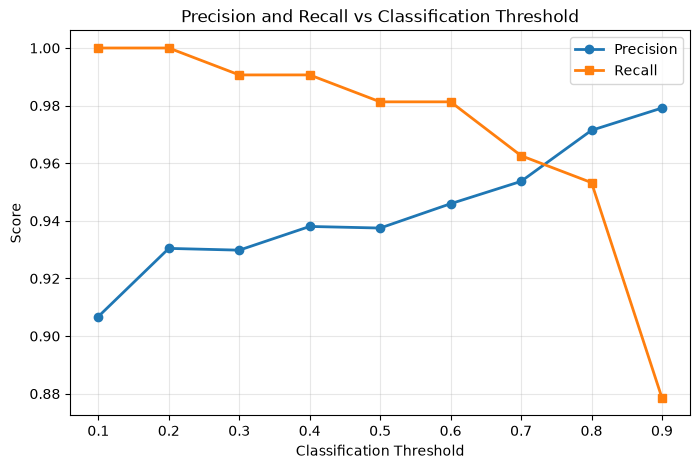

In [3]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(
    results["Threshold"],
    results["Precision"],
    marker="o",
    linewidth=2,
    label="Precision",
)

plt.plot(
    results["Threshold"],
    results["Recall"],
    marker="s",
    linewidth=2,
    label="Recall",
)

plt.xlabel("Classification Threshold")
plt.ylabel("Score")
plt.title("Precision and Recall vs Classification Threshold")
plt.grid(alpha=0.3)
plt.legend()

plt.show()

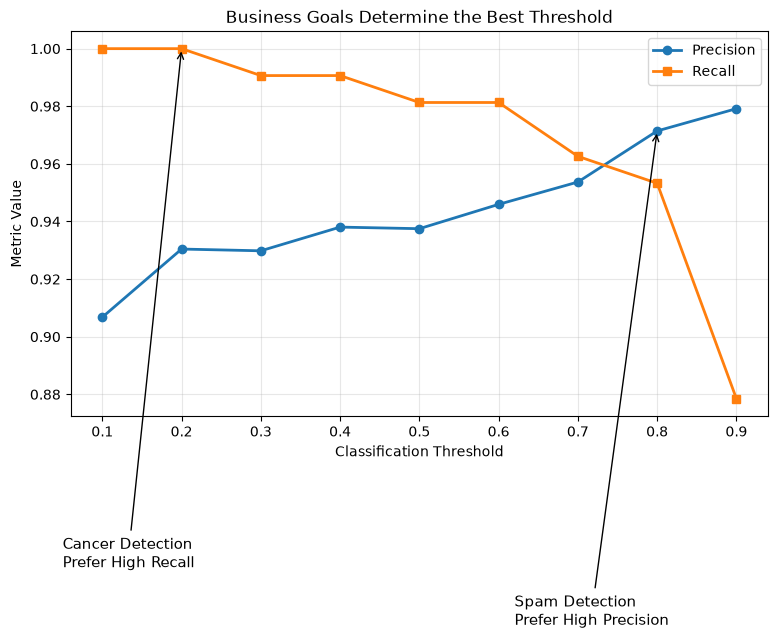

In [4]:
fig, ax = plt.subplots(figsize=(9,5))

ax.plot(
    results["Threshold"],
    results["Precision"],
    marker="o",
    linewidth=2,
    label="Precision",
)

ax.plot(
    results["Threshold"],
    results["Recall"],
    marker="s",
    linewidth=2,
    label="Recall",
)

# Cancer region
ax.annotate(
    "Cancer Detection\nPrefer High Recall",
    xy=(0.2, results.loc[1, "Recall"]),
    xytext=(0.05, 0.82),
    arrowprops=dict(arrowstyle="->"),
    fontsize=11,
)

# Spam region
ax.annotate(
    "Spam Detection\nPrefer High Precision",
    xy=(0.8, results.loc[7, "Precision"]),
    xytext=(0.62, 0.80),
    arrowprops=dict(arrowstyle="->"),
    fontsize=11,
)

ax.set_xlabel("Classification Threshold")
ax.set_ylabel("Metric Value")
ax.set_title("Business Goals Determine the Best Threshold")
ax.grid(alpha=0.3)
ax.legend()

plt.show()


# Choosing the Right Metric

| Application | Important Metric |
|-------------|------------------|
| Spam Detection | Precision |
| Disease Diagnosis | Recall |
| General Classification | F1-score |
| Balanced Dataset | Accuracy |

There is no universally best metric.

The correct metric depends on the problem.

---

# Classroom Activity

Suppose a disease detection system reports:

| Metric | Value |
|--------|------:|
| Accuracy | 99% |
| Recall | 10% |

Ask students:

- Would you trust this system?
- Why or why not?

Discuss the dangers of relying only on Accuracy.

---




## Example: Fraud Detection

Suppose a bank has:

- 100 fraudulent transactions
- 900 legitimate transactions

The model predicts only **one** transaction as fraud.

Confusion matrix:

| | Actual Fraud | Actual Legitimate |
|-|-:|-:|
| **Predicted Fraud** | 1 (TP) | 0 (FP) |
| **Predicted Not Fraud** | 99 (FN) | 900 (TN) |

---

## Precision

$$
Precision=
\frac{TP}{TP+FP}
$$

Substitute values:

$$
Precision=
\frac{1}{1+0}
$$

$$
\boxed{Precision=1}
$$

The only fraud alert was correct.

---

## Recall

$$
Recall=
\frac{TP}{TP+FN}
$$

Substitute values:

$$
Recall=
\frac{1}{1+99}
$$

$$
\boxed{Recall=0.01}
$$

The model found only 1% of all fraud cases.

# F1 Score

The **F1 Score** combines **Precision** and **Recall** into a single metric.

$$
F_1 = 2 \times
\frac{\text{Precision} \times \text{Recall}}
{\text{Precision} + \text{Recall}}
$$

Unlike Accuracy, the F1 Score focuses only on the quality of the positive predictions.




---

## Why is it the Harmonic Mean?

You may wonder:

> Why don't we simply compute the average of Precision and Recall?

For example,

- Precision = 1.0
- Recall = 0.0

The **arithmetic mean** would be

$$
\frac{1.0+0.0}{2}=0.5
$$

A score of **0.5** suggests the model is performing moderately well.

However, this is misleading.

Although every predicted positive is correct (Precision = 1), the model **misses every actual positive case** (Recall = 0).

Such a model is practically useless.

The **harmonic mean** solves this problem by heavily penalizing situations where one metric is much smaller than the other.

For the same example,

$$
F_1 =
2\cdot
\frac{1\times0}{1+0}
=
0
$$

The F1 Score correctly indicates that the model has failed.

---

## Harmonic Mean vs Arithmetic Mean

| Precision | Recall | Arithmetic Mean | F1 Score |
|-----------|--------|----------------:|----------:|
| 1.00 | 1.00 | 1.00 | 1.00 |
| 0.90 | 0.90 | 0.90 | 0.90 |
| 1.00 | 0.00 | **0.50** | **0.00** |
| 0.80 | 0.40 | **0.60** | **0.53** |

Notice that the F1 Score becomes much smaller whenever Precision and Recall are unbalanced.

This encourages models that perform well on **both** metrics instead of excelling at only one.

---

## When is F1 More Important than Accuracy?

Accuracy measures the percentage of all correct predictions.

However, Accuracy can be misleading when the classes are **imbalanced**.

### Example

Suppose a medical dataset contains:

- 990 healthy patients
- 10 patients with cancer

A model predicts **everyone is healthy**.

| Metric | Value |
|--------|-------|
| Accuracy | 99% |
| Recall | 0% |
| F1 Score | 0 |

Although the Accuracy is very high, the model completely fails to detect cancer patients.

In applications where **False Positives** and **False Negatives** both matter, the **F1 Score** is usually a much better evaluation metric than Accuracy.

Typical examples include:

- Disease detection
- Fraud detection
- Spam filtering
- Manufacturing defect detection

---

## Key Takeaways

- Accuracy evaluates **overall correctness**.
- Precision evaluates **how reliable positive predictions are**.
- Recall evaluates **how many actual positives are found**.
- F1 Score balances Precision and Recall into a single number.
- Use the **F1 Score** when both False Positives and False Negatives are important, especially for **imbalanced datasets**.

# Practical Example: Evaluating a Classification Model

So far, we have learned several evaluation metrics:

- Accuracy
- Precision
- Recall
- F1 Score

Now let's train a **Logistic Regression** model and evaluate its performance using these metrics.

We'll use the **Breast Cancer Wisconsin Dataset**, a well-known binary classification dataset included in scikit-learn.

In [5]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

# Load dataset
data = load_breast_cancer()

X = data.data
y = data.target

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y,
)

# Train Logistic Regression
model = LogisticRegression(max_iter=10000)

model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

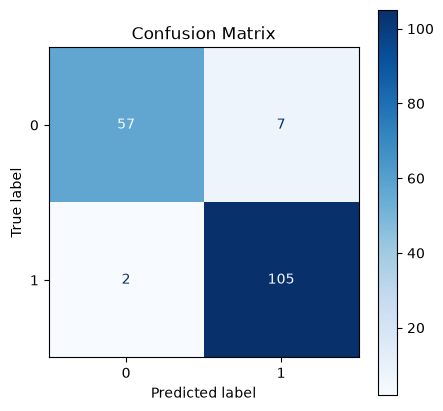

In [6]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(5,5))

ConfusionMatrixDisplay.from_estimator(
    model,
    X_test,
    y_test,
    cmap="Blues",
    ax=ax,
)

plt.title("Confusion Matrix")
plt.show()

### Interpreting the Confusion Matrix

Each cell represents the number of predictions made by the classifier.

- **True Positives (TP):** Positive samples correctly classified.
- **True Negatives (TN):** Negative samples correctly classified.
- **False Positives (FP):** Negative samples incorrectly predicted as positive.
- **False Negatives (FN):** Positive samples incorrectly predicted as negative.

A perfect classifier would have all predictions on the main diagonal.

In [7]:
from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    y_pred,
    target_names=data.target_names,
))

              precision    recall  f1-score   support

   malignant       0.97      0.89      0.93        64
      benign       0.94      0.98      0.96       107

    accuracy                           0.95       171
   macro avg       0.95      0.94      0.94       171
weighted avg       0.95      0.95      0.95       171



### Understanding the Classification Report

The report summarizes several evaluation metrics for each class.

| Metric | Meaning |
|---------|---------|
| Precision | Of all predicted positives, how many were correct? |
| Recall | Of all actual positives, how many were detected? |
| F1 Score | Harmonic mean of Precision and Recall |
| Support | Number of true samples belonging to each class |

Notice that the report provides these metrics **for every class separately**, allowing us to understand how well the model performs on each category.

In [8]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
)

print(f"Accuracy : {accuracy_score(y_test, y_pred):.3f}")
print(f"Precision: {precision_score(y_test, y_pred):.3f}")
print(f"Recall   : {recall_score(y_test, y_pred):.3f}")
print(f"F1 Score : {f1_score(y_test, y_pred):.3f}")

Accuracy : 0.947
Precision: 0.938
Recall   : 0.981
F1 Score : 0.959


## Discussion

Even though this model achieves a high Accuracy, we should **not** rely on Accuracy alone.

A complete evaluation considers multiple metrics:

- **Accuracy** measures overall correctness.
- **Precision** measures how trustworthy positive predictions are.
- **Recall** measures how many actual positive cases are detected.
- **F1 Score** balances Precision and Recall.

In real-world applications, the choice of the most important metric depends on the problem.

- Medical diagnosis → prioritize **Recall**
- Spam filtering → prioritize **Precision**
- General binary classification → often compare models using **F1 Score**

# Week 7 – Day 2  
# Session 2 

# Trustworthy Model Evaluation

---

# Session Overview

In the previous session, we learned how to measure machine learning performance using evaluation metrics:

- Accuracy
- Precision
- Recall
- F1-score
- MSE
- RMSE
- R²

However, an important question remains:

> **Can we trust these evaluation results?**

A model may achieve excellent performance during development but fail when deployed on real-world data.

In this session, we learn how machine learning engineers evaluate models reliably by understanding:

- Overfitting
- Underfitting
- Bias–Variance Tradeoff
- Train / Validation / Test Split
- Data Leakage
- Cross Validation

---

# Learning Objectives

By the end of this session, students will be able to:

- Explain why training performance is not enough.
- Identify overfitting and underfitting.
- Understand the bias–variance tradeoff.
- Explain the purpose of Training, Validation, and Test datasets.
- Recognize data leakage problems.
- Apply K-Fold Cross Validation.
- Understand when to use Stratified K-Fold.

---



# Part 1 — Generalization and Model Reliability (25 Minutes)

## Opening Question

Consider two models:

### Model A



Training Accuracy = 100%

Testing Accuracy = 70%



### Model B



Training Accuracy = 92%

Testing Accuracy = 90%



Question:

> Which model should we deploy?

The correct answer is **Model B**.

Why?

Because machine learning is not about memorizing existing examples.

It is about making accurate predictions on **new unseen data**.

---

# Generalization

## Definition

Generalization is the ability of a model to perform well on data it has never seen before.

The goal of machine learning:



Training Data


    ↓


Learn Patterns


    ↓


New Data


    ↓


Correct Predictions



A model with good generalization can transfer what it learned to real-world situations.

---

In [16]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score


# Create data
np.random.seed(42)

X = np.random.rand(200, 1) * 10

# Real relationship:
# y = 3x + noise
y = 3 * X[:, 0] + np.random.randn(200) * 2


# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)


# Train model
model = LinearRegression()
model.fit(X_train, y_train)


# Evaluate
train_score = model.score(X_train, y_train)
test_score = model.score(X_test, y_test)


print("Training R²:", train_score)
print("Testing R² :", test_score)

Training R²: 0.956373226438267
Testing R² : 0.9413122748521374


## Interpretation
- Training and testing performance are close.
- The model learned the underlying pattern.
- The model has good **generalization**.


# Overfitting

## Definition

Overfitting happens when a model learns the training data too closely.

It learns:

- Useful patterns
- Noise
- Random variations

As a result:



Training Performance  ↑↑↑

Testing Performance  ↓



---

# Example

A decision tree with unlimited depth:



Small Dataset


    ↓


Many Branches


    ↓


Memorizes Examples


    ↓


Poor Generalization



---

# Symptoms of Overfitting

Common signs:

- Very high training accuracy
- Lower test accuracy
- Large gap between train and test results
- Extremely complex model

---

# Example 2 — Overfitting: Decision Tree Memorizing Data

Decision trees are powerful because they can learn complex patterns.

However, if we allow unlimited depth, the tree may memorize the training data.

---

## Create a Nonlinear Dataset


In [26]:
from sklearn.datasets import make_moons
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score


# Generate classification data
X, y = make_moons(
    n_samples=100,
    noise=0.35,
    random_state=42
)


# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42
)

# Very complex decision tree
tree = DecisionTreeClassifier(
    max_depth=None,
    random_state=42
)


tree.fit(X_train, y_train)


# Evaluate
train_accuracy = accuracy_score(
    y_train,
    tree.predict(X_train)
)

test_accuracy = accuracy_score(
    y_test,
    tree.predict(X_test)
)

print("Training Accuracy:", train_accuracy)
print("Testing Accuracy :", test_accuracy)

Training Accuracy: 0.9142857142857143
Testing Accuracy : 0.9


## Visualize Decision Boundary


<Figure size 700x500 with 0 Axes>

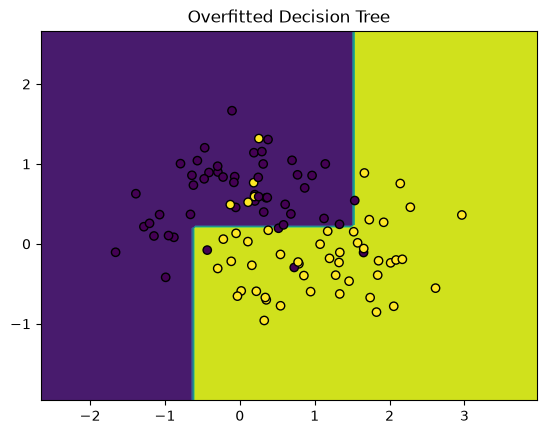

In [27]:
from sklearn.inspection import DecisionBoundaryDisplay


plt.figure(figsize=(7,5))

DecisionBoundaryDisplay.from_estimator(
    tree,
    X,
    response_method="predict"
)

plt.scatter(
    X[:,0],
    X[:,1],
    c=y,
    edgecolor="black"
)

plt.title("Overfitted Decision Tree")

plt.show()

## Observation:

The model creates many complicated regions.

It learns:

- Real patterns
- Noise
- Random variations

Result:

```
Training Performance ↑↑↑

Testing Performance  ↓
```

This is **overfitting**.


# Underfitting

## Definition

Underfitting occurs when the model is too simple to learn important patterns.

The model cannot capture the relationship between inputs and outputs.

Result:



Training Performance  Low

Testing Performance   Low



---

# Causes of Underfitting

Examples:

- Model is too simple
- Not enough features
- Excessive regularization
- Insufficient training

---

## Generate Nonlinear Data


In [28]:
from sklearn.preprocessing import PolynomialFeatures


np.random.seed(42)


X = np.linspace(
    -3,
    3,
    100
).reshape(-1,1)


# Nonlinear relationship
y = X[:,0]**3 + np.random.randn(100)*5


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

## Train a Simple Linear Model


In [29]:
model = LinearRegression()

model.fit(
    X_train,
    y_train
)


train_r2 = model.score(
    X_train,
    y_train
)

test_r2 = model.score(
    X_test,
    y_test
)


print("Training R²:", train_r2)
print("Testing R² :", test_r2)

Training R²: 0.7656587831720576
Testing R² : 0.7504346515680136


## Interpretation

Both scores are poor.

The model is not learning enough.

---

## Why?

The real relationship is:

```
y = x³
```

but the model assumes:

```
y = ax + b
```

The model is too simple.



Result:

```
Training Performance ↓

Testing Performance  ↓
```

This is **underfitting**.


# High Bias: Why Does It Mean a Simple Model?

## Intuition

A simple model has **limited ability to learn patterns**.

It makes strong assumptions about the data and cannot capture complex relationships.

It is like trying to describe the world using a very small set of rules.

# High Variance: Why Does It Mean a Complex Model?

## Intuition

A complex model has a very large capacity.

It can learn:

- Real patterns
- Small details
- Random noise

The problem is that it may treat random noise as if it were a meaningful pattern.


# Model Complexity Tradeoff



Model Complexity

Low -------------------- High

Underfit


↓


Good Fit


↓


Overfit



The goal is not the most complex model.

The goal is the model that generalizes best.

---

# Bias–Variance Tradeoff

Two sources of modeling error:

---

## High Bias

The model is too simple.

Characteristics:

- Strong assumptions
- Misses important patterns
- Underfitting

Example:



Linear Model
for a highly nonlinear problem



---

## High Variance

The model is too sensitive to training data.

Characteristics:

- Learns noise
- Changes significantly with new samples
- Overfitting

Example:



Very deep Decision Tree



---

# Key Idea

A good machine learning model balances:



Bias

*

Variance

=

Generalization Performance



---

# Example 4 — Bias–Variance Tradeoff

Different model complexities produce different behaviors.

We compare Decision Trees with different depths.

In [32]:
from sklearn.datasets import make_moons
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score


# Generate classification data
X, y = make_moons(
    n_samples=100,
    noise=0.35,
    random_state=42
)


# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42
)

In [40]:
depths = list(range(1, 6)) + [None]

train_scores = []
test_scores = []


for depth in depths:

    model = DecisionTreeClassifier(
        max_depth=depth,
        random_state=42
    )

    model.fit(
        X_train,
        y_train
    )

    train_scores.append(
        model.score(X_train, y_train)
    )

    test_scores.append(
        model.score(X_test, y_test)
    )


for d, train, test in zip(
    depths,
    train_scores,
    test_scores
):
    print(
        f"Depth={d}: "
        f"Train={train:.2f}, "
        f"Test={test:.2f}"
    )

Depth=1: Train=0.81, Test=0.80
Depth=2: Train=0.91, Test=0.90
Depth=3: Train=0.93, Test=0.87
Depth=4: Train=0.94, Test=0.87
Depth=5: Train=0.97, Test=0.73
Depth=None: Train=1.00, Test=0.73


# Interpretation

## Depth = 1

The model is too simple.

```
High Bias

Underfitting
```

---

## Depth = 6 or Unlimited

The model memorizes training examples.

```
High Variance

Overfitting
```

---

## Medium Depth

The model finds the balance.

```
Good Generalization
```


# Train, Validation and Test Data (20 Minutes)

## Why Training Accuracy Is Not Enough

Imagine a student who memorizes previous exam questions.

They may achieve:



100% on practice questions



but fail on new questions.

Machine learning models behave similarly.

---

# Dataset Splitting

A standard workflow:



Complete Dataset


    ↓


Training Set


    ↓


Validation Set


    ↓


Test Set



---

# Role of Each Dataset

| Dataset | Purpose |
|---------|---------|
| Training | Learn model parameters |
| Validation | Tune and compare models |
| Test | Final unbiased evaluation |

---

# The Golden Rule

> The Test Set must remain untouched until the final evaluation.

Do not use the Test Set for:

- Selecting features
- Choosing hyperparameters
- Comparing models repeatedly

---

# Data Leakage

## Definition

Data leakage happens when information from outside the training process accidentally influences the model.

In other words, data leakage (also called information leakage) occurs when a machine learning model has access to information during training that would not be available when making predictions in the real world.

This creates unrealistic performance.

---

# Example

Wrong workflow:



Train Model


  ↓


Evaluate on Test Data


  ↓


Change Model


  ↓


Evaluate Again


  ↓


Repeat



The model gradually becomes optimized for the test data.

The final score is no longer trustworthy.

---

# Correct Workflow



Training Data


    ↓


Model Development


    ↓


Validation


    ↓


Final Model


    ↓


Test Once



---

# Classroom Question

Which dataset should be used to select:



Decision Tree max_depth = ?



Options:

A) Training Set  
B) Validation Set  
C) Test Set  

Answer:



Validation Set



---

In [42]:
# Decision Tree with Train / Dev / Test Split

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score


# ==========================================
# 1. Load Dataset
# ==========================================

X, y = load_breast_cancer(return_X_y=True)


# ==========================================
# 2. Split Data
# ==========================================

# First split:
# 80% train+dev, 20% test

X_train_dev, X_test, y_train_dev, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


# Second split:
# From train+dev:
# 75% train, 25% dev
#
# Overall:
# Train = 60%
# Dev   = 20%
# Test  = 20%

X_train, X_dev, y_train, y_dev = train_test_split(
    X_train_dev,
    y_train_dev,
    test_size=0.25,
    random_state=42,
    stratify=y_train_dev
)


print("Dataset size:", X.shape)
print("Train size:", X_train.shape)
print("Dev size:", X_dev.shape)
print("Test size:", X_test.shape)


# ==========================================
# 3. Hyperparameter Selection Using Dev Set
# ==========================================

depths = range(1, 15)

train_scores = []
dev_scores = []


for depth in depths:

    model = DecisionTreeClassifier(
        max_depth=depth,
        random_state=42
    )

    # Train only on training data
    model.fit(
        X_train,
        y_train
    )

    # Evaluate on train
    train_accuracy = model.score(
        X_train,
        y_train
    )

    # Evaluate on development set
    dev_accuracy = model.score(
        X_dev,
        y_dev
    )

    train_scores.append(train_accuracy)
    dev_scores.append(dev_accuracy)


# Find best depth using dev set

best_depth = depths[
    dev_scores.index(
        max(dev_scores)
    )
]


print(
    "Best depth:",
    best_depth
)

print(
    "Best Dev Accuracy:",
    max(dev_scores)
)


# ==========================================
# 4. Train Final Model
# ==========================================

# Combine train + dev data

model = DecisionTreeClassifier(
    max_depth=best_depth,
    random_state=42
)


model.fit(
    X_train_dev,
    y_train_dev
)


# ==========================================
# 5. Final Evaluation on Test Set
# ==========================================

test_accuracy = model.score(
    X_test,
    y_test
)


print(
    "Final Test Accuracy:",
    test_accuracy
)

Dataset size: (569, 30)
Train size: (341, 30)
Dev size: (114, 30)
Test size: (114, 30)
Best depth: 5
Best Dev Accuracy: 0.956140350877193
Final Test Accuracy: 0.9210526315789473


# Cross Validation (30 Minutes)

## Why Do We Need Cross Validation?

Suppose we split data randomly:

Experiment 1:



Accuracy = 90%



Experiment 2:



Accuracy = 84%



Which one is correct?

A single split may depend on chance.

---

# K-Fold Cross Validation

Cross Validation evaluates a model multiple times using different parts of the dataset.

Example:



K = 5



Dataset:



Fold 1
Fold 2
Fold 3
Fold 4
Fold 5



Each fold becomes the validation set once.

---

# Process

Iteration 1:



Validation

Fold 1

Training:

Fold 2
Fold 3
Fold 4
Fold 5



Iteration 2:



Validation

Fold 2

Training:

Fold 1
Fold 3
Fold 4
Fold 5



Continue until all folds are tested.

---

# Final Cross Validation Score

The final score is the average:

\[
CV =
\frac{1}{K}
\sum_{i=1}^{K} Score_i
\]

Example:



Fold Scores:

90%
91%
89%
92%
90%

Average:

90.4%



---

# Advantages of Cross Validation

Cross Validation:

- Uses all samples for evaluation
- Reduces randomness
- Provides a more stable estimate
- Helps compare models fairly

---

# Choosing K

| K | Usage |
|---|---|
| 5 | Common default |
| 10 | More reliable estimate |
| Large K | More computation |

In practice:



K = 5 or 10



is usually a good choice.

---

In [43]:
# Linear Regression with K-Fold Cross Validation

import numpy as np

from sklearn.datasets import load_diabetes
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import KFold, cross_val_score
from sklearn.metrics import mean_squared_error


# ==========================================
# 1. Load Dataset
# ==========================================

X, y = load_diabetes(
    return_X_y=True
)


print("Features shape:", X.shape)
print("Target shape:", y.shape)


# ==========================================
# 2. Define Model
# ==========================================

model = LinearRegression()


# ==========================================
# 3. Define K-Fold Cross Validation
# ==========================================

kfold = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)


# ==========================================
# 4. Evaluate Model Using Cross Validation
# ==========================================

# R² scores for each fold

r2_scores = cross_val_score(
    model,
    X,
    y,
    cv=kfold,
    scoring="r2"
)


print("\nR² scores for each fold:")

for i, score in enumerate(r2_scores):
    print(
        f"Fold {i+1}: {score:.3f}"
    )


print(
    "\nAverage R²:",
    r2_scores.mean()
)


# ==========================================
# 5. Evaluate RMSE
# ==========================================

rmse_scores = np.sqrt(
    -cross_val_score(
        model,
        X,
        y,
        cv=kfold,
        scoring="neg_mean_squared_error"
    )
)


print("\nRMSE scores for each fold:")

for i, score in enumerate(rmse_scores):
    print(
        f"Fold {i+1}: {score:.2f}"
    )


print(
    "\nAverage RMSE:",
    rmse_scores.mean()
)

Features shape: (442, 10)
Target shape: (442,)

R² scores for each fold:
Fold 1: 0.453
Fold 2: 0.573
Fold 3: 0.391
Fold 4: 0.584
Fold 5: 0.391

Average R²: 0.47847030225778475

RMSE scores for each fold:
Fold 1: 53.85
Fold 2: 51.60
Fold 3: 57.55
Fold 4: 52.90
Fold 5: 58.34

Average RMSE: 54.84894090589967


# Stratified K-Fold

## Problem

Many classification datasets are imbalanced.

Example:



Fraud Detection

Fraud:
1%

Normal:
99%



A random split may create a validation set without enough fraud samples.

---

# Solution: Stratification

Stratified K-Fold keeps class proportions similar in every fold.

Original:



99% Normal

1% Fraud



Each Fold:



99% Normal

1% Fraud



---

# When to Use Stratified K-Fold?

Recommended for:

- Binary classification
- Multi-class classification
- Imbalanced datasets

---

# Classroom Exercise

Five folds produce:

| Fold | Accuracy |
|------|---------:|
| 1 | 90% |
| 2 | 91% |
| 3 | 89% |
| 4 | 92% |
| 5 | 90% |

Discuss:

1. Is the model stable?
2. Would you trust this result?
3. Why is the average better than one measurement?

---

# Session Summary

Today we learned:

## Generalization

A model must perform well on unseen data.

## Overfitting

The model memorizes training data.

## Underfitting

The model is too simple.

## Dataset Splitting

Training, Validation, and Test have different roles.

## Data Leakage

Using future or unavailable information creates unreliable results.

## Cross Validation

Provides a more reliable estimate of model performance.

## Stratified K-Fold

Improves evaluation for imbalanced classification problems.

---



# Model Selection and Hyperparameter Tuning

## The Big Picture

In machine learning, we usually have two important decisions:

1. **Which type of model should we use?**
   - **Model Selection**

2. **What are the best settings for that model?**
   - **Hyperparameter Tuning**

Both decisions affect the model's ability to **generalize** to unseen data.

---

## 1. Model Selection

### Definition

**Model selection** is the process of choosing the best machine learning algorithm among different candidate models.

The question is:

> "Which model architecture is most suitable for this problem?"

---

### Example

Suppose we want to predict whether a customer will leave a company (**churn prediction**).

Possible models:

- Logistic Regression
- Decision Tree
- Random Forest
- Support Vector Machine
- Neural Network

Each model learns patterns differently.

Example results:

| Model | Validation Accuracy |
|---|---:|
| Logistic Regression | 88% |
| Decision Tree | 84% |
| Random Forest | 92% |
| SVM | 90% |

Based on the results, we select:

`Random Forest`

because it gives the best expected performance on unseen data.

---

### Intuition

Think about choosing a car for a trip.

Different models are different types of cars:

- Sedan
- SUV
- Sports car
- Truck

Before choosing the exact settings of the car, you first decide:

> "Which type of car is suitable for this journey?"

That is **model selection**.

---

## 2. Hyperparameter Tuning

### Definition

After choosing a model, we need to find the best values for its **hyperparameters**.

Hyperparameters are settings that control how the model learns.

They are chosen **before training**.

---

### Example: Decision Tree

A Decision Tree has hyperparameters such as:

```python
max_depth
min_samples_split
criterion
```

Different choices create different models.

Example:

| max_depth | Accuracy |
| --------- | -------: |
| 2         |      82% |
| 5         |      91% |
| 10        |      88% |
| None      |      84% |

The best choice is:

```python
max_depth = 5
```

---

### Intuition

After choosing the type of car (model selection), you tune the settings:

* Tire pressure
* Engine mode
* Fuel efficiency settings

These adjustments improve performance.

That is **hyperparameter tuning**.

---

## Difference Between Model Selection and Hyperparameter Tuning

|               | Model Selection               | Hyperparameter Tuning               |
| ------------- | ----------------------------- | ----------------------------------- |
| Main question | Which algorithm should I use? | What settings should I use?         |
| Changes       | Model type                    | Model configuration                 |
| Example       | Random Forest vs SVM          | Random Forest with 100 vs 500 trees |
| Search space  | Different algorithms          | Different parameter values          |

---

## How K-Fold Cross Validation Is Used

K-fold cross-validation is used to **estimate how well a model will perform on unseen data**.

Instead of relying on one train/validation split, we train and evaluate the model multiple times.

---

## K-Fold for Model Selection

Suppose we want to compare different algorithms.

Candidate models:

```text
Model 1: Logistic Regression
Model 2: Decision Tree
Model 3: Random Forest
```

Using 5-fold cross-validation:

| Model               | Fold 1 | Fold 2 | Fold 3 | Fold 4 | Fold 5 | Average |
| ------------------- | -----: | -----: | -----: | -----: | -----: | ------: |
| Logistic Regression |    88% |    90% |    87% |    89% |    91% |   89.0% |
| Decision Tree       |    84% |    86% |    82% |    85% |    83% |   84.0% |
| Random Forest       |    92% |    93% |    91% |    94% |    92% |   92.4% |

The model with the highest average performance is selected.

Result:

`Selected Model = Random Forest`

---

## K-Fold for Hyperparameter Tuning

After selecting Random Forest, we tune its parameters.

Example:

Try different values of:

```python
n_estimators
max_depth
```

Possible results:

| n_estimators | max_depth | CV Accuracy |
| ------------ | --------- | ----------: |
| 100          | 5         |         90% |
| 200          | 5         |         92% |
| 100          | 10        |         91% |
| 200          | 10        |         93% |

The best configuration:

```python
n_estimators = 200
max_depth = 10
```

---

## Complete Machine Learning Workflow

```text
                 Dataset
                    |
                    |
          Split into Train/Test
                    |
                    |
             Training Data
                    |
                    |
        +----------------------+
        |                      |
  Model Selection       Hyperparameter Tuning
        |                      |
        |                      |
 Compare Algorithms       Try Parameters
        |                      |
        +----------+-----------+
                   |
                   |
          Use K-Fold Cross Validation
                   |
                   |
        Select Best Model + Parameters
                   |
                   |
        Train Final Model
                   |
                   |
        Evaluate Once on Test Set
```

---

## Example with Scikit-Learn

### Model Selection

Compare models using cross-validation:

In [47]:
from sklearn.model_selection import KFold, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor


# Define regression models
models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(random_state=42)
}


# Define K-Fold Cross Validation
cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)


# Compare models
for name, model in models.items():

    scores = cross_val_score(
        model,
        X,
        y,
        cv=cv,
        scoring="r2"
    )

    print(
        f"{name}: {scores.mean():.3f}"
    )

Linear Regression: 0.478
Decision Tree: -0.133
Random Forest: 0.429


Selected model:

`Random Forest`

---

### Hyperparameter Tuning Example

Now tune Random Forest:

In [48]:
from sklearn.model_selection import GridSearchCV, KFold
from sklearn.tree import DecisionTreeRegressor


# Define Decision Tree model
model = DecisionTreeRegressor(
    random_state=42
)


# Define only max_depth values to test
param_grid = {
    "max_depth": [2, 3, 5, 7, 10, 15, None]
}


# Define K-Fold Cross Validation
cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)


# Create GridSearchCV
grid_search = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    cv=cv,
    scoring="r2"
)


# Run hyperparameter tuning
grid_search.fit(
    X_train,
    y_train
)


# Best hyperparameter
print("Best max_depth:")
print(grid_search.best_params_)


# Best CV score
print("\nBest CV R2 Score:")
print(grid_search.best_score_)

Best max_depth:
{'max_depth': 2}

Best CV R2 Score:
0.7680552844773504


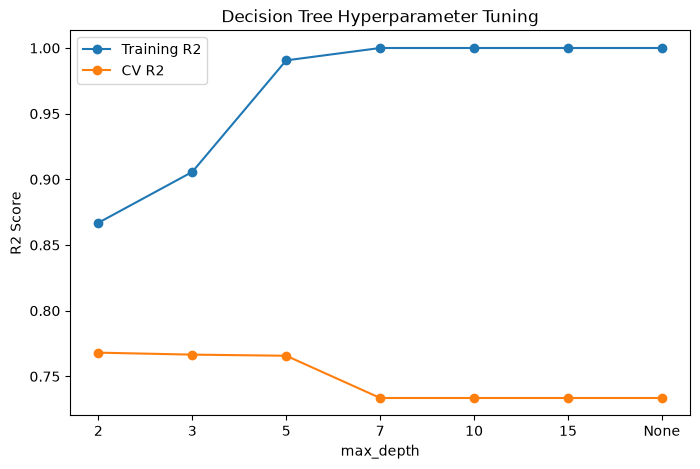

In [49]:
import matplotlib.pyplot as plt


depths = [2, 3, 5, 7, 10, 15, None]

train_scores = []
cv_scores = []


for depth in depths:

    model = DecisionTreeRegressor(
        max_depth=depth,
        random_state=42
    )

    model.fit(
        X_train,
        y_train
    )

    train_scores.append(
        model.score(X_train, y_train)
    )

    cv_score = grid_search.cv_results_[
        "mean_test_score"
    ][depths.index(depth)]

    cv_scores.append(cv_score)


plt.figure(figsize=(8,5))

plt.plot(
    [str(d) for d in depths],
    train_scores,
    marker="o",
    label="Training R2"
)

plt.plot(
    [str(d) for d in depths],
    cv_scores,
    marker="o",
    label="CV R2"
)

plt.xlabel("max_depth")
plt.ylabel("R2 Score")
plt.title("Decision Tree Hyperparameter Tuning")
plt.legend()
plt.show()

# Grid Search Cross Validation

1. Creates different hyperparameter combinations.
2. Applies K-fold cross-validation to each combination.
3. Calculates average performance.
4. Selects the best combination.

---

## Important: Keep the Test Set Separate

A common mistake is using the test set for model selection.

### Incorrect

```text
Train → Try models → Choose best using Test Data
```

The test set becomes part of the learning process.

---

### Correct

```text
Training Data
      |
      |
K-fold Cross Validation
      |
      |
Choose Model + Hyperparameters
      |
      |
Final Evaluation on Test Set
```

In [50]:
from sklearn.model_selection import GridSearchCV, KFold
from sklearn.tree import DecisionTreeRegressor


# Define the Decision Tree model
model = DecisionTreeRegressor(
    random_state=42
)


# Define hyperparameter search space
param_grid = {
    "max_depth": [3, 5, 10, 15, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 5],
    "criterion": [
        "squared_error",
        "absolute_error"
    ]
}


# Define K-Fold Cross Validation
cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)


# Create GridSearchCV
grid_search = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    cv=cv,
    scoring="r2",
    n_jobs=-1
)


# Run hyperparameter tuning
grid_search.fit(
    X_train,
    y_train
)


# Best hyperparameters
print("Best Parameters:")
print(grid_search.best_params_)


# Best cross-validation score
print("\nBest CV R2 Score:")
print(grid_search.best_score_)

Best Parameters:
{'criterion': 'squared_error', 'max_depth': 3, 'min_samples_leaf': 2, 'min_samples_split': 2}

Best CV R2 Score:
0.7844115778158518


---

## Key Takeaway

* **Model selection** chooses **which algorithm** to use.
* **Hyperparameter tuning** chooses the **best settings** for that algorithm.
* **K-fold cross-validation** provides a reliable way to compare models and hyperparameter combinations by estimating their performance on unseen data.
* The final test set should only be used **once**, after all decisions have been made.

# Intuitive Explanation of R² (Coefficient of Determination) (further reading)

## The Big Idea

**R² measures how much better your regression model is compared to simply predicting the average value.**

Imagine you want to predict house prices.

Before seeing **any features** (such as house size, number of bedrooms, or location), the best prediction you can make is the **average house price**.

For example:

| House | Actual Price ($k) |
|--------|------------------:|
| A | 180 |
| B | 210 |
| C | 250 |
| D | 160 |
| E | 200 |

Average price:

$$
\bar{y}=200
$$

Without any information about the houses, your predictions would be:

```text
200
200
200
200
200
```

Clearly, these predictions are not very accurate.

---

## Now Train a Regression Model

Suppose the model uses house size and predicts:

| House | Actual | Predicted |
|--------|--------|----------:|
| A | 180 | 185 |
| B | 210 | 205 |
| C | 250 | 245 |
| D | 160 | 170 |
| E | 200 | 195 |

These predictions are much closer to the actual prices.

The important question becomes:

> **How much better is this model than simply predicting the average?**

That is exactly what **R²** measures.

---

## Visual Interpretation

Imagine the actual prices spread around their average.

```text
250 ●
240
230
220
210 ●
200 ●  ← Average
190
180 ●
170
160 ●
```

Predicting the average ignores all of this variation.

A good regression model explains why some houses cost more and others cost less.

---

## Thinking in Terms of Error

### Method 1: Always Predict the Mean

```text
Actual:      180   210   250   160   200
Prediction:  200   200   200   200   200
```

The prediction errors are large.

---

### Method 2: Regression Model

```text
Actual:      180   210   250   160   200
Prediction:  185   205   245   170   195
```

The prediction errors are much smaller.

---

## What Does R² Measure?

R² answers the following question:

> **What percentage of the original prediction error has the model eliminated?**

For example:

- Eliminates **100%** of the error → **R² = 1**
- Eliminates **80%** of the error → **R² = 0.80**
- Eliminates **50%** of the error → **R² = 0.50**
- Eliminates **0%** of the error → **R² = 0**

---

## Another Analogy: Predicting Exam Scores

Suppose you're trying to predict students' exam scores.

Without knowing anything about the students, your safest prediction is the class average.

Suppose the average score is **75**.

```text
Student A : 95
Student B : 80
Student C : 60
Student D : 65

Prediction:
75
75
75
75
```

Now suppose you know:

- Hours studied
- Attendance

Your regression model predicts:

```text
94
82
61
66
```

These predictions are much closer to the actual scores.

If the model explains **90% of the differences between students**, then

$$
R^2 = 0.90
$$

---

## What Does "Explained Variance" Mean?

People often say:

> **R² is the proportion of variance explained by the model.**

Intuitively, this means:

Every dataset contains natural variation.

For example, house prices vary:

```text
160
170
180
190
200
210
220
230
240
250
```

A regression model tries to explain **why** these values differ.

For example:

- Larger houses cost more.
- Better locations increase price.
- More bedrooms increase value.

The more of this variation the model can explain, the higher the R².

---

## Mathematical Interpretation

R² compares two quantities:

- **Total variation** in the target values.
- **Remaining variation** after the model makes predictions.

The mathematical formula is

$$
R^2
=
1-
\frac{SS_{res}}
{SS_{tot}}
$$

where

- $SS_{res}$ = Residual Sum of Squares (prediction error)
- $SS_{tot}$ = Total Sum of Squares (variation from the mean)

Interpretation:

- If the model makes perfect predictions:

$$
SS_{res}=0
\quad\Rightarrow\quad
R^2=1
$$

- If the model is no better than predicting the mean:

$$
SS_{res}=SS_{tot}
\quad\Rightarrow\quad
R^2=0
$$

- If the model is even worse than predicting the mean:

$$
SS_{res}>SS_{tot}
\quad\Rightarrow\quad
R^2<0
$$

---

## Interpretation of Common Values

| R² | Interpretation |
|----|----------------|
| 1.00 | Perfect prediction |
| 0.90 | Explains about 90% of the variation |
| 0.70 | Good fit |
| 0.50 | Explains half of the variation |
| 0.20 | Weak relationship |
| 0.00 | No better than predicting the mean |
| < 0 | Worse than predicting the mean |

---

## An Intuitive Formula

Although the mathematical definition is based on sums of squares, a useful way to think about R² is

$$
R^2
=
\frac{\text{Variation Explained by the Model}}
{\text{Total Variation in the Data}}
$$

This formula captures the intuition behind R² even though it is not the exact computational formula.

---

## A Simple Analogy

Imagine a 100-piece jigsaw puzzle.

- Predicting the **mean** is like putting all the pieces into one pile—you haven't explained anything.
- A regression model starts assembling the puzzle.

If the model reconstructs:

- **100%** of the picture → **R² = 1**
- **80%** of the picture → **R² ≈ 0.8**
- **50%** of the picture → **R² ≈ 0.5**
- **None** of the picture → **R² = 0**

The more of the hidden pattern your model discovers, the higher its R².

---

# Key Takeaway

> **R² measures how much of the variation in the target variable is explained by the regression model, compared to simply predicting the average value.**

- **R² = 1** means perfect predictions.
- **R² = 0** means the model is no better than predicting the mean.
- **R² < 0** means the model performs even worse than the mean predictor.

A high R² indicates that the model has successfully captured much of the underlying relationship between the input features and the target variable.